# TikTok Claims Classification

**Google Advanced Data Analytics Professional Certificate**

Classification of TikTok videos based on metadata and textual features to identify whether a claim is likely to require verification.

# 1. Plan
The objective of this project is to develop a machine learning model capable of distinguishing **claim** videos from **opinion** videos on TikTok.

Accurately identifying claims is an important step in content moderation workflows, as factual claims may require additional verification before being recommended or widely distributed. To address this problem, this project follows the **PACE (Plan, Analyze, Construct, Execute)** framework, guiding the analysis from business understanding to model development and evaluation.

This section defines the business problem, project objectives, analytical approach, and success criteria that will guide the remaining phases of the project.

## 1.1 Business Context
The rapid growth of user-generated content on social media platforms has made content moderation increasingly challenging. TikTok receives a large volume of videos every day, making it impractical to manually review every piece of content before it reaches users.

To support moderation efforts, machine learning models can help identify videos that are more likely to contain factual claims requiring verification. By prioritizing these videos for human review, the platform can allocate moderation resources more efficiently while helping reduce the spread of potentially misleading information.

This project explores whether video metadata and textual features can be used to classify TikTok videos according to the likelihood that they contain a claim requiring verification.

## 1.2 Problem Statement
The primary challenge is to develop a classification model capable of distinguishing videos that contain claims requiring verification from those that express opinions or other forms of content.

An accurate model could assist moderation teams by prioritizing content for manual review, reducing response time and improving the efficiency of the moderation process.

## 1.3 Objectives
- Explore and understand the available dataset.
- Perform data cleaning and preprocessing.
- Engineer relevant features for classification.
- Train and evaluate multiple machine learning models.
- Compare model performance using appropriate classification metrics.
- Recommend the most suitable model for supporting TikTok's content moderation workflow.

## 1.4 Success Metrics
Model performance will be evaluated using classification metrics, including:
- Accuracy
- Precision
- Recall
- F1-score
Given the moderation context, particular attention will be given to Recall, as failing to identify videos containing potentially misleading claims may have greater consequences than reviewing additional non-claim videos.

# 2. Analyze
The **Analyze** phase focuses on understanding the dataset through inspection, cleaning, exploratory data analysis, and statistical validation.

The goal is to identify data quality issues, explore relationships between variables, and uncover patterns that may contribute to predicting whether a video contains a claim or an opinion. The insights obtained during this phase will directly inform feature engineering and model development.

## 2.1 Import Libraries
This section imports all libraries required throughout the project.

The imported packages support data manipulation, visualization, feature engineering, statistical analysis, and machine learning model development. Centralizing all imports at the beginning of the notebook improves readability and reproducibility.

In [1]:
# ==========================================
# Data manipulation
# ==========================================

import numpy as np
import pandas as pd

# Display options
pd.set_option("display.max_columns", None)

# ==========================================
# Data visualization
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ==========================================
# Statistical analysis
# ==========================================

from scipy import stats

# ==========================================
# Feature Engineering
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer

# ==========================================
# Machine Learning
# ==========================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
# from xgboost import plot_importance

## 2.2 Load Dataset
The dataset is loaded into a pandas DataFrame, which will serve as the primary structure for data exploration, preprocessing, visualization, and model development throughout the project.

In [106]:
df = pd.read_csv("../data/tiktok_dataset.csv")
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


## 2.3 Initial Inspection
This section provides an overview of the dataset, including its dimensions, data types, missing values, duplicated records, and summary statistics. These checks help identify potential data quality issues before proceeding with cleaning and exploratory analysis.

In [107]:
# Dataset Overview
print(f"Dataset shape: {df.shape}")

df.info()

Dataset shape: (19382, 12)
<class 'pandas.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  str    
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  str    
 5   verified_status           19382 non-null  str    
 6   author_ban_status         19382 non-null  str    
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), str(4)
memory usage: 1.8 MB


### Findings
- The dataset contains **19,382 observations** and **12 variables**.
- Features include a combination of numerical and categorical variables describing video characteristics, author status, engagement metrics, and claim labels.
- Overall, the dataset appears well-structured and suitable for exploratory analysis after handling missing values.

In [108]:
# Summary Statistics
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


### Findings
- Video duration ranges from **5 to 60 seconds**, with a median duration of **32 seconds**.
- Engagement metrics (views, likes, shares, downloads, and comments) exhibit a **high degree of variability**, indicating the presence of highly viral videos.
- Large differences between the median and maximum values suggest that several numerical variables are **right-skewed** and may contain outliers.
- These characteristics will be explored further during the exploratory data analysis phase.

In [109]:
# Missing Values
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame(name="Missing Values")
)

missing_values

,Missing Values
claim_status,298
video_transcription_text,298
video_view_count,298
video_like_count,298
video_share_count,298
video_download_count,298
video_comment_count,298
#,0
video_id,0
video_duration_sec,0


### Findings
- Seven variables contain **298 missing values**, representing approximately **1.5%** of the dataset.
- Missing values occur across both the target variable and several engagement-related features.
- Because the proportion of missing data is relatively small, these observations may be removed during the data cleaning stage without substantially affecting the analysis.

In [110]:
# Duplicate Rows
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [111]:
# Target Variable

df["claim_status"].value_counts()

claim_status
claim      9608
opinion    9476
Name: count, dtype: int64

### Findings
- The target variable is **well balanced**, with similar numbers of *claim* and *opinion* observations.
- This balanced distribution reduces the risk of model bias toward one class and simplifies model evaluation.

## 2.4 Data Cleaning
The initial inspection identified a small number of missing values but no duplicate records. This section focuses on cleaning the dataset, removing incomplete observations, and ensuring the data is ready for exploratory analysis and model development.

In [112]:
# Create a working copy
df_clean = df.copy()

# Remove rows containing missing values
df_clean = df_clean.dropna()
print(df_clean.shape)

(19084, 12)


In [113]:
# Verify missing values
df_clean.isnull().sum()

#                           0
claim_status                0
video_id                    0
video_duration_sec          0
video_transcription_text    0
verified_status             0
author_ban_status           0
video_view_count            0
video_like_count            0
video_share_count           0
video_download_count        0
video_comment_count         0
dtype: int64

In [114]:
# Reset index
df_clean.reset_index(drop=True, inplace=True)

In [115]:
# Check final dataset
print(f"Final dataset shape: {df_clean.shape}")

Final dataset shape: (19084, 12)


### Data Cleaning Summary
The cleaning process removed a small number of incomplete observations while preserving the overall integrity of the dataset. No duplicate records were identified, and all remaining observations contain complete information. The cleaned dataset is now ready for exploratory data analysis.

## 2.5 Exploratory Data Analysis
This section explores the relationships between video characteristics, account information, engagement metrics, and the target variable. The objective is to identify patterns, detect potential predictors, and generate insights that may improve the classification models.

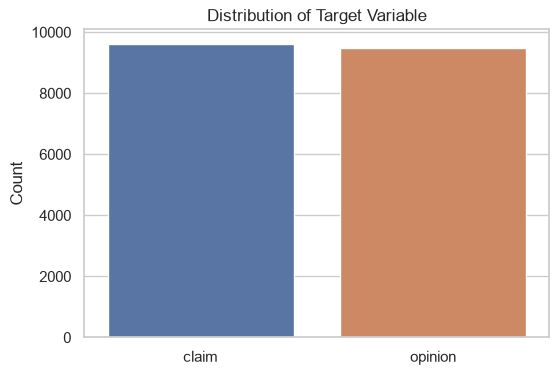

In [116]:
## 2.5.1 Target Variable Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_clean,
    x="claim_status",
    hue="claim_status",
    legend=False
)

plt.title("Distribution of Target Variable")
plt.xlabel("")
plt.ylabel("Count")

plt.show()

### Key Insights
- The dataset is almost perfectly balanced between **claims** and **opinions**.
- Because the classes have similar frequencies, model training is unlikely to suffer from class imbalance.
- Accuracy can therefore be interpreted with greater confidence during model evaluation.

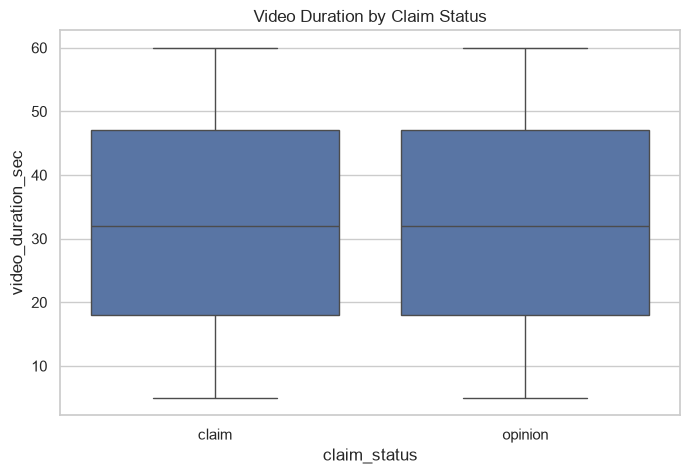

In [117]:
## 2.5.2 Video Duration
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="claim_status",
    y="video_duration_sec"
)

plt.title("Video Duration by Claim Status")

plt.show()

### Key Insights
- This visualization compares video duration across the two target classes.
- Differences in the distributions may indicate that video length contributes to distinguishing claims from opinions.
- Outliers are limited because video duration is naturally constrained between 5 and 60 seconds.

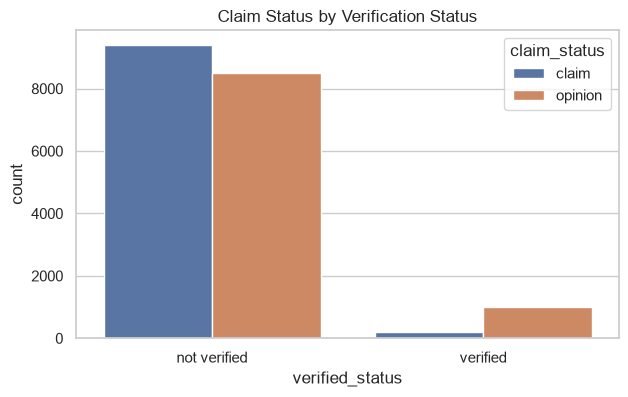

In [118]:
## 2.5.3 Verified Status
plt.figure(figsize=(7,4))

sns.countplot(
    data=df_clean,
    x="verified_status",
    hue="claim_status"
)

plt.title("Claim Status by Verification Status")

plt.show()

### Key Insights
- Most videos were posted by non-verified accounts.
- Comparing verification status across target classes helps determine whether account verification is associated with claims or opinions.

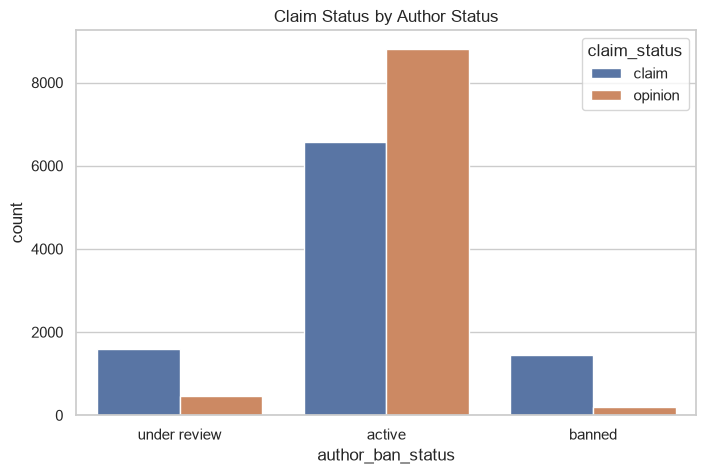

In [119]:
## 2.5.4 Author Ban Status
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="author_ban_status",
    hue="claim_status"
)

plt.title("Claim Status by Author Status")

plt.show()

### Key Insights
- Author status may provide useful predictive information.
- Videos from banned or under-review accounts could exhibit different behavior from active accounts.

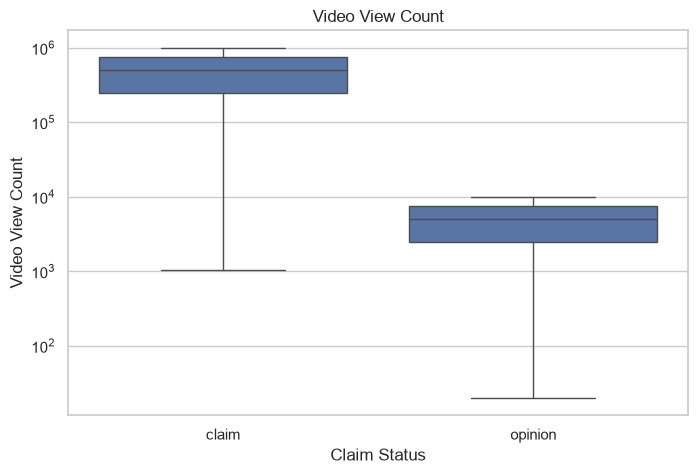

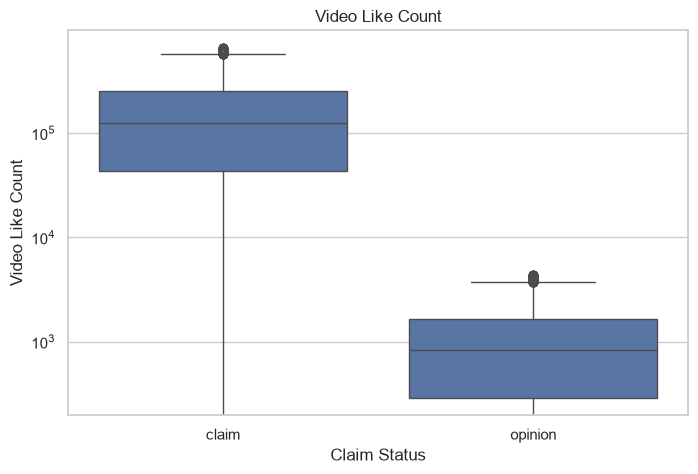

In [120]:
## 2.5.5 Engagement Metrics
metrics = [
    "video_view_count",
    "video_like_count"
]

for metric in metrics:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df_clean,
        x="claim_status",
        y=metric
    )

    plt.yscale("log")

    plt.title(metric.replace("_"," ").title())

    plt.xlabel("Claim Status")
    plt.ylabel(metric.replace("_"," ").title())

    plt.show()

### Key Insights
- Claim videos receive substantially higher engagement than opinion videos.
- Engagement metrics are highly right-skewed, with a small number of viral videos generating extremely large values.
- Logarithmic scaling improves the comparison by reducing the influence of extreme outliers.

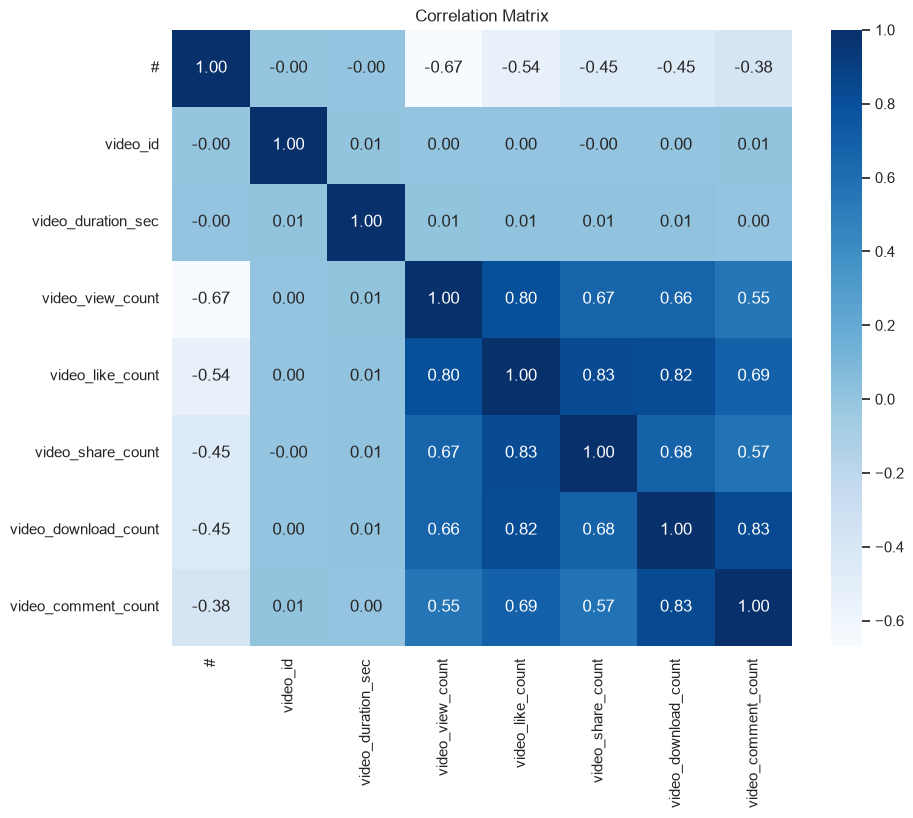

In [121]:
## 2.5.6 Correlation Analysis
plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.select_dtypes(include="number").corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Key Insights
- Engagement variables are expected to exhibit moderate to strong positive correlations.
- Highly correlated features may contain redundant information but also help identify meaningful behavioral patterns.

### Exploratory Analysis Summary
The exploratory analysis revealed that the dataset is balanced and contains several potentially informative predictors. Account verification status, author status, engagement metrics, and video duration all appear to have relationships with the target variable. Additionally, engagement variables display strong variability and positive correlations, suggesting that feature engineering and appropriate preprocessing will be important before model development.

In [122]:
df_clean.groupby("claim_status")[[
    "video_view_count",
    "video_like_count",
    "video_share_count",
    "video_comment_count"
]].median()

,video_view_count,video_like_count,video_share_count,video_comment_count
claim_status,,,,
claim,501555.0,123649.0,17997.5,286.0
opinion,4953.0,823.0,121.0,1.0


## 2.6 Statistical Validation
The exploratory analysis suggested that claim videos receive substantially more engagement than opinion videos. To verify whether this observed difference is statistically significant, an independent samples t-test is performed.

In [123]:
from scipy.stats import ttest_ind

claim = df_clean.loc[
    df_clean["claim_status"] == "claim",
    "video_view_count"
]

opinion = df_clean.loc[
    df_clean["claim_status"] == "opinion",
    "video_view_count"
]

t_stat, p_value = ttest_ind(
    claim,
    opinion,
    equal_var=False
)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.6f}")

T-statistic: 166.89
P-value: 0.000000


### Key Insights
- The p-value is substantially below the conventional significance level of 0.05.
- Therefore, the null hypothesis is rejected, indicating that the difference in video views between claim and opinion videos is statistically significant.
- This result supports the findings from the exploratory analysis and suggests that video engagement is likely to be an informative feature for predicting claim status.

# 2.7 Analysis Conclusions
The analysis phase provided a comprehensive understanding of the TikTok claims dataset and identified several patterns that will guide the modeling stage.

### Main Findings
- The dataset is balanced between **claim** and **opinion** classes, making it suitable for binary classification.
- Missing values represented only a small proportion of the data and were removed without significantly reducing the dataset size.
- No duplicate records were identified.
- Claim videos consistently exhibited substantially higher engagement than opinion videos across views, likes, shares, comments, and downloads.
- Verified accounts represent only a small portion of the dataset, while most authors have active accounts.
- Engagement variables are strongly correlated, suggesting they capture related aspects of user interaction.
- Statistical testing confirmed that the difference in engagement between claim and opinion videos is statistically significant.

### Implications for Modeling
The exploratory analysis suggests that engagement metrics, account characteristics, and video duration are likely to be informative predictors for distinguishing between claims and opinions.
The cleaned dataset is now ready for feature engineering, preprocessing, and model development.

# 3. Construct
The **Construct** phase focuses on transforming the cleaned dataset into a format suitable for machine learning.

Based on the insights obtained during the analysis phase, new features are engineered, categorical variables are encoded, and the dataset is prepared for model training. These preprocessing steps ensure that the predictive models can effectively learn patterns associated with claim classification while maintaining reproducibility and minimizing data leakage.

# 3.1 Feature Engineering
Feature engineering aims to create additional variables that may improve model performance by extracting meaningful information from the existing dataset.

Based on the exploratory analysis, both textual and numerical features appear to contain valuable predictive information. This step focuses on transforming the raw data into features that better represent the underlying characteristics of each video.

In [124]:
## Feature 1 — Text Length
df_model = df_clean.copy()

df_model["transcription_length"] = (
    df_model["video_transcription_text"]
    .str.len()
)

### Key Insights
The number of characters in the video transcription may reflect content complexity or speaking style, potentially helping distinguish claims from opinions.

In [125]:
## Feature 2 — Word Count
df_model["word_count"] = (
    df_model["video_transcription_text"]
    .str.split()
    .str.len()
)

### Key Insights
Word count captures the amount of spoken content in each video and may provide additional predictive information beyond simple text length.

In [126]:
## Feature 3 — Engagement Ratio
df_model["like_view_ratio"] = (
    df_model["video_like_count"]
    /
    df_model["video_view_count"]
)

df_model["like_view_ratio"] = (
    df_model["like_view_ratio"]
    .fillna(0)
)

### Key Insights
The like-to-view ratio measures audience engagement relative to exposure, providing a normalized indicator of how users interact with each video.

In [127]:
## Feature 4 — Comment Ratio
df_model["comment_view_ratio"] = (
    df_model["video_comment_count"]
    /
    df_model["video_view_count"]
)

df_model["comment_view_ratio"] = (
    df_model["comment_view_ratio"]
    .fillna(0)
)

### Feature Engineering Summary
Four new features were created to enrich the dataset.

- **Transcription Length** captures the number of characters in each video's transcript.
- **Word Count** measures the amount of spoken content.
- **Like-to-View Ratio** represents audience engagement normalized by exposure.
- **Comment-to-View Ratio** captures the tendency of viewers to actively interact with the content.

These engineered features complement the original dataset and may improve the predictive performance of the machine learning models.

## 3.2 Data Preprocessing
Machine learning algorithms require numerical and consistently formatted input data. This section prepares the engineered dataset by selecting the features, encoding categorical variables, removing unnecessary columns, and defining the target variable.

In [128]:
## Remove unecessary columns
columns_to_drop = [
    "video_id",
    "video_transcription_text"
]

df_model = df_model.drop(columns=columns_to_drop)

### Key Insights
The video identifier does not contain predictive information, while the raw transcription text is excluded from the initial models. Instead, engineered features derived from the transcription are used to capture textual information in a structured format.

In [129]:
## Coding categorical variables
df_model = pd.get_dummies(
    df_model,
    columns=[
        "verified_status",
        "author_ban_status"
    ],
    drop_first=True
)
df_model.head()

,#,claim_status,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,transcription_length,word_count,like_view_ratio,comment_view_ratio,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,claim,59,343296.0,19425.0,241.0,1.0,0.0,97,16,0.056584,0.000000,False,False,True
1,2,claim,32,140877.0,77355.0,19034.0,1161.0,684.0,107,19,0.549096,0.004855,False,False,False
2,3,claim,31,902185.0,97690.0,2858.0,833.0,329.0,137,23,0.108282,0.000365,False,False,False
3,4,claim,25,437506.0,239954.0,34812.0,1234.0,584.0,131,24,0.548459,0.001335,False,False,False
4,5,claim,19,56167.0,34987.0,4110.0,547.0,152.0,128,22,0.622910,0.002706,False,False,False


### Key Insights
Categorical variables were transformed using one-hot encoding, allowing the machine learning algorithms to interpret categorical information without introducing artificial ordinal relationships.

In [130]:
## Create target variable
df_model["claim_status"] = (
    df_model["claim_status"]
    .map({
        "opinion": 0,
        "claim": 1
    })
)

### Key Insights
The target variable was encoded as a binary outcome, where **0** represents opinion videos and **1** represents claim videos. This format is required for binary classification algorithms.

In [131]:
## Separate features and target variable
X = df_model.drop(columns="claim_status")
y = df_model["claim_status"]

y.head()

0    1
1    1
2    1
3    1
4    1
Name: claim_status, dtype: int64

### Key Insights
The dataset is now fully numerical and separated into predictor variables (`X`) and the target variable (`y`), making it ready for train-test splitting and model development.

# 3.3 Train-Test Split
Before training the machine learning models, the dataset is divided into separate training and testing sets.

The **training set** is used to fit the models, while the **testing set** is reserved for evaluating their performance on previously unseen data. This separation provides a more realistic estimate of how well the models are expected to generalize to new observations.

Since the target variable is well balanced, **stratified sampling** is applied to preserve the class distribution in both datasets.

In [132]:
## Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Key Insights
- The dataset was divided into **80% training** and **20% testing** subsets.
- Stratified sampling ensured that both subsets preserve the original class distribution.
- The testing set will remain unseen during training and will be used exclusively for evaluating model performance.

In [133]:
## Verify class distribution
train_distribution = (
    y_train
    .value_counts(normalize=True)
    .rename("Training")
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .rename("Testing")
)

pd.concat([train_distribution, test_distribution], axis=1)

,Training,Testing
claim_status,,
1,0.503439,0.503537
0,0.496561,0.496463


### Key Insights
- The class proportions remained virtually identical after the train-test split.
- Maintaining a balanced distribution reduces the risk of introducing sampling bias and supports reliable model evaluation.

### Train-Test Split Summary
The dataset was successfully partitioned into training and testing subsets using stratified sampling. This approach preserves the original class balance while ensuring that model evaluation is performed on previously unseen data.

With the data properly prepared, the next step is to train and evaluate the first baseline classification model.

## 3.4 Model Selection
The objective of this project is to classify TikTok videos as either **claims** or **opinions**, which is a binary classification problem involving a combination of numerical engagement metrics and categorical account characteristics.

Random Forest was selected because it is well-suited for structured tabular data and can naturally capture complex, non-linear relationships and interactions between features without requiring extensive assumptions about the underlying data distribution.

Unlike linear models, Random Forest is robust to outliers, handles mixed feature types effectively, and provides estimates of feature importance, making it particularly valuable for understanding which variables contribute most to distinguishing claim videos from opinion videos.

For these reasons, Random Forest was chosen as the primary modeling approach for this classification task.

## 3.5 Model Training

In [134]:
## Train Model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### Key Insights
The Random Forest classifier was successfully trained using the training dataset. During training, the algorithm built multiple decision trees using bootstrap sampling and random feature selection, reducing variance and improving generalization compared to a single decision tree.

In [135]:
## Generate predictions
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

### Key Insights
Predicted classes and prediction probabilities were generated for the testing dataset. These outputs will be used to evaluate classification performance and visualize the model's discriminative ability.

## 3.6 Model Evaluation

In [136]:
accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [137]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1895
           1       1.00      1.00      1.00      1922

    accuracy                           1.00      3817
   macro avg       1.00      1.00      1.00      3817
weighted avg       1.00      1.00      1.00      3817



## 3.7 Model Comparison

## 3.8 Final Model